# ESE 5971 — Milestone 2

## Traffic Signal Timing Optimization for Urban Intersections

This notebook provides reproducible data analysis
for Milestone 2.

Data source: ETH Zurich Traffic Signal Control Dataset.

The dataset contains traffic signal states and
loop detector occupancy recorded at one urban
intersection in January and February 2019.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Find the dataset from the project root or notebooks folder.
zip_name = "Traffic_Signal_Control_Dataset.zip"

candidates = [
    Path.cwd() / "data" / "raw" / zip_name,
    Path.cwd().parent / "data" / "raw" / zip_name
]

zip_path = next(
    (p for p in candidates if p.is_file()),
    None
)

if zip_path is None:
    raise FileNotFoundError(
        "Dataset not found. Place the ZIP file in data/raw/."
    )

# Files in chronological order
csv_files = [
    "intersection_data_set_jan_01_15.csv",
    "intersection_data_set_jan_16_31.csv",
    "intersection_data_set_feb_01_15.csv",
    "intersection_data_set_feb_16_28.csv"
]

with ZipFile(zip_path) as z:
    available_files = z.namelist()

assert all(name in available_files for name in csv_files)

print("Dataset found:", zip_path)
print("CSV files:", len(csv_files))
print("All required files are available.")

Dataset found: c:\Users\17381\Downloads\traffic-signal-m2\data\raw\Traffic_Signal_Control_Dataset.zip
CSV files: 4
All required files are available.


In [2]:
with ZipFile(zip_path) as z:
    with z.open(csv_files[0]) as f:
        sample = pd.read_csv(f, nrows=10)

print("Dataset shape (preview):", sample.shape)

print("\nColumn names:")
print(sample.columns.tolist())

print("\nFirst five rows:")
display(sample.head())

Dataset shape (preview): (10, 23)

Column names:
['time', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'd9', 'd10', 'sg1', 'sg2', 'sg3', 'sg4', 'sg5', 'sg6', 'sg7', 'sg8', 'sg9', 'sg10', 'sg11', 'sg12']

First five rows:


,time,d1,d2,d3,d4,d5,d6,d7,d8,d9,...,sg3,sg4,sg5,sg6,sg7,sg8,sg9,sg10,sg11,sg12
0,2019-01-01 05:37:15,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2019-01-01 05:37:16,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2019-01-01 05:37:17,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2019-01-01 05:37:18,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,2019-01-01 05:37:19,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [3]:
file_summary = []

with ZipFile(zip_path) as z:
    for filename in csv_files:

        total_rows = 0
        start_time = None
        end_time = None

        with z.open(filename) as f:
            for chunk in pd.read_csv(
                f,
                usecols=["time"],
                parse_dates=["time"],
                chunksize=200_000
            ):
                total_rows += len(chunk)

                if start_time is None:
                    start_time = chunk["time"].iloc[0]

                end_time = chunk["time"].iloc[-1]

        file_summary.append({
            "filename": filename,
            "rows": total_rows,
            "start_time": start_time,
            "end_time": end_time
        })

summary_df = pd.DataFrame(file_summary)

display(summary_df)

print("Total rows:", summary_df["rows"].sum())

,filename,rows,start_time,end_time
0,intersection_data_set_jan_01_15.csv,1275758,2019-01-01 05:37:15,2019-01-15 23:59:52
1,intersection_data_set_jan_16_31.csv,1382220,2019-01-16 00:02:58,2019-01-31 23:59:57
2,intersection_data_set_feb_01_15.csv,1295567,2019-02-01 00:07:09,2019-02-15 23:59:55
3,intersection_data_set_feb_16_28.csv,1122877,2019-02-16 00:05:21,2019-02-28 23:59:57


Total rows: 5076422


## 2. Data Quality and Missingness

This section checks missing values, invalid detector states,
and unusual signal group codes.

The purpose is to understand potential data quality and
measurement problems before building predictive models.

In [4]:
# Define detector and signal group columns
detector_cols = [f"d{i}" for i in range(1, 11)]
signal_cols = [f"sg{i}" for i in range(1, 13)]

all_cols = ["time"] + detector_cols + signal_cols

# Initialize counters
missing_counts = pd.Series(0, index=all_cols, dtype="int64")
invalid_detector = pd.Series(0, index=detector_cols, dtype="int64")
signal_code_8 = pd.Series(0, index=signal_cols, dtype="int64")
other_signal_codes = pd.Series(0, index=signal_cols, dtype="int64")

total_rows = 0

with ZipFile(zip_path) as z:
    for filename in csv_files:
        with z.open(filename) as f:
            for chunk in pd.read_csv(f, chunksize=200_000):

                total_rows += len(chunk)

                # Missing values
                missing_counts += chunk[all_cols].isna().sum()

                # Detector values should be 0 or 1
                invalid_detector += (
                    ~chunk[detector_cols].isin([0, 1])
                    & chunk[detector_cols].notna()
                ).sum()

                # Count unusual signal code 8
                signal_code_8 += (
                    chunk[signal_cols] == 8
                ).sum()

                # Check for any other unexpected codes
                other_signal_codes += (
                    ~chunk[signal_cols].isin([0, 1, 8])
                    & chunk[signal_cols].notna()
                ).sum()

print("Total rows:", total_rows)
print("Total missing values:", int(missing_counts.sum()))

print("\nMissing values by column:")
display(missing_counts.to_frame("Missing Count"))

print("\nInvalid detector values:")
display(invalid_detector.to_frame("Invalid Count"))

print("\nSignal code 8 counts:")
display(signal_code_8.to_frame("Count of 8"))

print("\nOther signal codes:")
display(other_signal_codes.to_frame("Unexpected Count"))

Total rows: 5076422
Total missing values: 0

Missing values by column:


,Missing Count
time,0
d1,0
d2,0
d3,0
d4,0
d5,0
d6,0
d7,0
d8,0
d9,0



Invalid detector values:


,Invalid Count
d1,0
d2,0
d3,0
d4,0
d5,0
d6,0
d7,0
d8,0
d9,0
d10,0



Signal code 8 counts:


,Count of 8
sg1,834975
sg2,834975
sg3,834975
sg4,834975
sg5,834975
sg6,834975
sg7,834975
sg8,834975
sg9,834975
sg10,834975



Other signal codes:


,Unexpected Count
sg1,0
sg2,0
sg3,0
sg4,0
sg5,0
sg6,0
sg7,0
sg8,0
sg9,0
sg10,0


In [5]:
previous_time = None
missing_seconds = 0
duplicate_times = 0
out_of_order = 0

first_time = None
last_time = None

with ZipFile(zip_path) as z:
    for filename in csv_files:
        with z.open(filename) as f:

            for chunk in pd.read_csv(
                f,
                usecols=["time"],
                chunksize=200_000
            ):

                ts = pd.to_datetime(
                    chunk["time"],
                    errors="coerce"
                )

                if ts.isna().any():
                    raise ValueError(
                        "Invalid timestamps found."
                    )

                if first_time is None:
                    first_time = ts.iloc[0]

                # Differences within the chunk
                diffs = ts.diff().dt.total_seconds().dropna()

                # Check boundary between chunks/files
                if previous_time is not None:
                    boundary_diff = (
                        ts.iloc[0] - previous_time
                    ).total_seconds()

                    diffs = pd.concat([
                        pd.Series([boundary_diff]),
                        diffs
                    ], ignore_index=True)

                missing_seconds += int(
                    (diffs[diffs > 1] - 1).sum()
                )

                duplicate_times += int((diffs == 0).sum())
                out_of_order += int((diffs < 0).sum())

                previous_time = ts.iloc[-1]
                last_time = previous_time

print("First timestamp:", first_time)
print("Last timestamp:", last_time)

print("Missing seconds within recorded range:",
      missing_seconds)

print("Duplicate timestamps:", duplicate_times)
print("Out-of-order timestamps:", out_of_order)

# Full calendar coverage: January and February 2019
calendar_start = pd.Timestamp("2019-01-01")
calendar_end = pd.Timestamp("2019-03-01")

expected_seconds = int(
    (calendar_end - calendar_start).total_seconds()
)

print("\nExpected seconds:", expected_seconds)
print("Observed records:", total_rows)
print("Missing calendar seconds:",
      expected_seconds - total_rows)

print("Missing calendar percentage:",
      round(
          (expected_seconds - total_rows)
          / expected_seconds * 100,
          4
      ),
      "%"
)

First timestamp: 2019-01-01 05:37:15
Last timestamp: 2019-02-28 23:59:57
Missing seconds within recorded range: 941
Duplicate timestamps: 0
Out-of-order timestamps: 0

Expected seconds: 5097600
Observed records: 5076422
Missing calendar seconds: 21178
Missing calendar percentage: 0.4155 %


## 3. Signal State Investigation

This section investigates the undocumented signal code 8
and examines its temporal distribution.

The purpose is to identify possible operational patterns
without assuming that code 8 represents a data error.

In [6]:
# Investigate signal code 8 across all CSV files

hour_total = np.zeros(24, dtype=np.int64)
hour_code8 = np.zeros(24, dtype=np.int64)

any8_count = 0
all8_count = 0

with ZipFile(zip_path) as z:
    for filename in csv_files:
        with z.open(filename) as f:
            for chunk in pd.read_csv(
                f, chunksize=200_000
            ):

                # First 10 signal groups
                sg = chunk[signal_cols[:10]]

                # Check whether code 8 appears simultaneously
                any8 = sg.eq(8).any(axis=1)
                all8 = sg.eq(8).all(axis=1)

                any8_count += int(any8.sum())
                all8_count += int(all8.sum())

                # Extract hour of day
                hours = pd.to_datetime(
                    chunk["time"]
                ).dt.hour.to_numpy()

                # Count observations for each hour
                hour_total += np.bincount(
                    hours, minlength=24
                )

                # Count simultaneous code 8 observations
                hour_code8 += np.bincount(
                    hours[all8.to_numpy()],
                    minlength=24
                )

# Calculate hourly percentages
hourly_df = pd.DataFrame({
    "Hour": range(24),
    "Total Observations": hour_total,
    "Code 8 Observations": hour_code8
})

hourly_df["Code 8 Percentage"] = (
    hourly_df["Code 8 Observations"]
    / hourly_df["Total Observations"] * 100
)

print("Any sg1-sg10 contains 8:", any8_count)
print("All sg1-sg10 contain 8:", all8_count)

print(
    "Mixed code 8 observations:",
    any8_count - all8_count
)

display(hourly_df)

Any sg1-sg10 contains 8: 834975
All sg1-sg10 contain 8: 834975
Mixed code 8 observations: 0


,Hour,Total Observations,Code 8 Observations,Code 8 Percentage
0,0,207872,0,0.000000
1,1,208800,207004,99.139847
2,2,208800,208800,100.000000
3,3,208800,208800,100.000000
4,4,208800,208800,100.000000
5,5,210165,0,0.000000
6,6,212400,0,0.000000
7,7,212400,0,0.000000
8,8,212400,0,0.000000
9,9,212400,0,0.000000


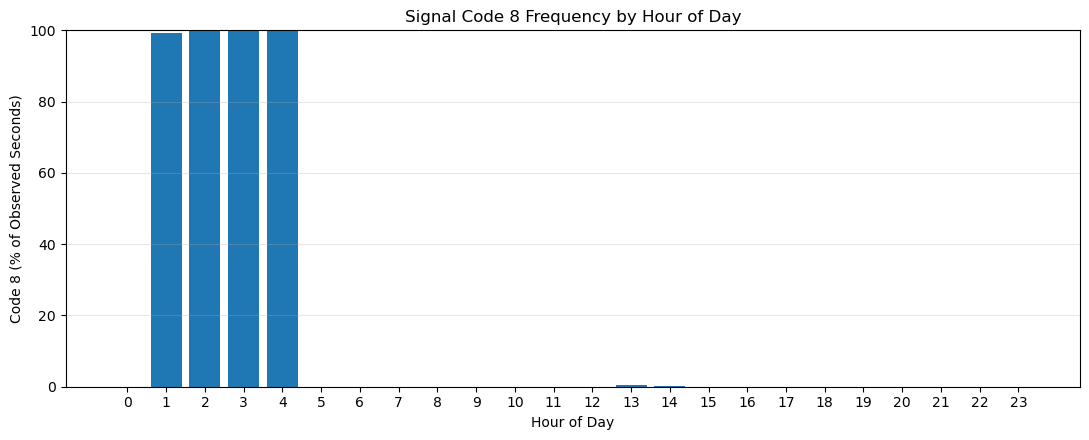

In [7]:
# Plot hourly distribution of code 8

fig, ax = plt.subplots(figsize=(11, 4.5))

ax.bar(
    hourly_df["Hour"],
    hourly_df["Code 8 Percentage"]
)

ax.set_title(
    "Signal Code 8 Frequency by Hour of Day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Code 8 (% of Observed Seconds)")

ax.set_xticks(range(24))
ax.set_ylim(0, 100)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save figure to the project figures directory
project_root = zip_path.resolve().parent.parent.parent
figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

fig.savefig(
    figures_dir / "signal_code8_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Descriptive Analysis and EDA

This section analyzes detector occupancy and its temporal patterns.

The original observations are recorded every second.
We aggregate them into 5-minute intervals to reduce data size
and study traffic patterns over time.

Detector occupancy represents the proportion of observed
seconds during which a detector is occupied.
It is not a direct measurement of vehicle volume or delay.

In [8]:
# Aggregate detector data into 5-minute intervals

aggregated_parts = []

with ZipFile(zip_path) as z:
    for filename in csv_files:
        with z.open(filename) as f:

            for chunk in pd.read_csv(
                f,
                usecols=["time"] + detector_cols,
                chunksize=200_000
            ):

                chunk["time"] = pd.to_datetime(
                    chunk["time"]
                )

                # Define 5-minute time intervals
                chunk["bin_5min"] = (
                    chunk["time"].dt.floor("5min")
                )

                grouped = chunk.groupby("bin_5min")

                # Count occupied seconds
                sums = grouped[detector_cols].sum()

                # Count actual observed seconds
                sums["observed_seconds"] = grouped.size()

                aggregated_parts.append(sums)

# Combine partial results
agg_5min = (
    pd.concat(aggregated_parts)
    .groupby(level=0)
    .sum()
    .sort_index()
)

# Calculate detector occupancy fractions
occ_5min = agg_5min[detector_cols].div(
    agg_5min["observed_seconds"],
    axis=0
)

occ_5min.columns = [
    f"{col}_occ" for col in detector_cols
]

occ_5min["observed_seconds"] = (
    agg_5min["observed_seconds"]
)

occ_5min.index.name = "time"

print("Number of 5-minute intervals:", len(occ_5min))

print(
    "Intervals with fewer than 300 observed seconds:",
    (occ_5min["observed_seconds"] < 300).sum()
)

display(occ_5min.head())

# Summary statistics
occupancy_cols = [
    f"d{i}_occ" for i in range(1, 11)
]

summary_stats = (
    occ_5min[occupancy_cols]
    .describe()
    .T
)

display(summary_stats)

Number of 5-minute intervals: 16923
Intervals with fewer than 300 observed seconds: 8


,d1_occ,d2_occ,d3_occ,d4_occ,d5_occ,d6_occ,d7_occ,d8_occ,d9_occ,d10_occ,observed_seconds
time,,,,,,,,,,,
2019-01-01 05:35:00,0.000000,0.000000,0.00,0.024242,0.012121,0.072727,0.224242,0.00,0.036364,0.006061,165
2019-01-01 05:40:00,0.000000,0.000000,0.00,0.010000,0.020000,0.000000,0.020000,0.00,0.020000,0.010000,300
2019-01-01 05:45:00,0.086667,0.016667,0.02,0.026667,0.033333,0.066667,0.093333,0.03,0.016667,0.006667,300
2019-01-01 05:50:00,0.000000,0.000000,0.00,0.016667,0.043333,0.013333,0.083333,0.00,0.036667,0.006667,300
2019-01-01 05:55:00,0.000000,0.000000,0.00,0.170000,0.006667,0.016667,0.073333,0.00,0.030000,0.003333,300


,count,mean,std,min,25%,50%,75%,max
d1_occ,16923.0,0.055591,0.064688,0.0,0.000000,0.013333,0.106667,1.000000
d2_occ,16923.0,0.007684,0.010571,0.0,0.000000,0.006667,0.013333,0.666667
d3_occ,16923.0,0.012915,0.018252,0.0,0.000000,0.010000,0.020000,0.253333
d4_occ,16923.0,0.044063,0.108756,0.0,0.003333,0.013333,0.026667,0.993333
d5_occ,16923.0,0.055033,0.068926,0.0,0.010000,0.030000,0.073333,0.783333
d6_occ,16923.0,0.029173,0.034280,0.0,0.000000,0.016667,0.043333,0.333333
d7_occ,16923.0,0.092859,0.078474,0.0,0.000000,0.090000,0.153333,0.540000
d8_occ,16923.0,0.016034,0.021138,0.0,0.000000,0.013333,0.026667,0.630000
d9_occ,16923.0,0.027577,0.025574,0.0,0.010000,0.023333,0.040000,0.856667
d10_occ,16923.0,0.011440,0.010840,0.0,0.003333,0.010000,0.016667,0.193333


,d1_occ,d2_occ,d3_occ,d4_occ,d5_occ,d6_occ,d7_occ,d8_occ,d9_occ,d10_occ
hour,,,,,,,,,,
0,0.017775,0.003305,0.005304,0.011711,0.011841,0.019571,0.060154,0.006133,0.013967,0.003145
1,0.000000,0.000000,0.000038,0.006236,0.010445,0.000019,0.000000,0.000000,0.013257,0.002385
2,0.000000,0.000000,0.000029,0.005383,0.009124,0.000230,0.000019,0.000000,0.011216,0.001739
3,0.000000,0.000000,0.000081,0.003587,0.006853,0.000206,0.000000,0.000000,0.007941,0.001911
4,0.000000,0.000000,0.000034,0.004588,0.007380,0.000115,0.000000,0.000000,0.006786,0.002529
5,0.022781,0.005010,0.007490,0.005167,0.009710,0.008014,0.027410,0.009367,0.007733,0.003786
6,0.058051,0.009416,0.016540,0.007429,0.024798,0.031850,0.095009,0.017180,0.015589,0.007717
7,0.068027,0.011789,0.014120,0.011747,0.099948,0.036356,0.104798,0.021238,0.032156,0.013046
8,0.069995,0.009633,0.014873,0.018776,0.134713,0.037166,0.116238,0.020866,0.043931,0.014732


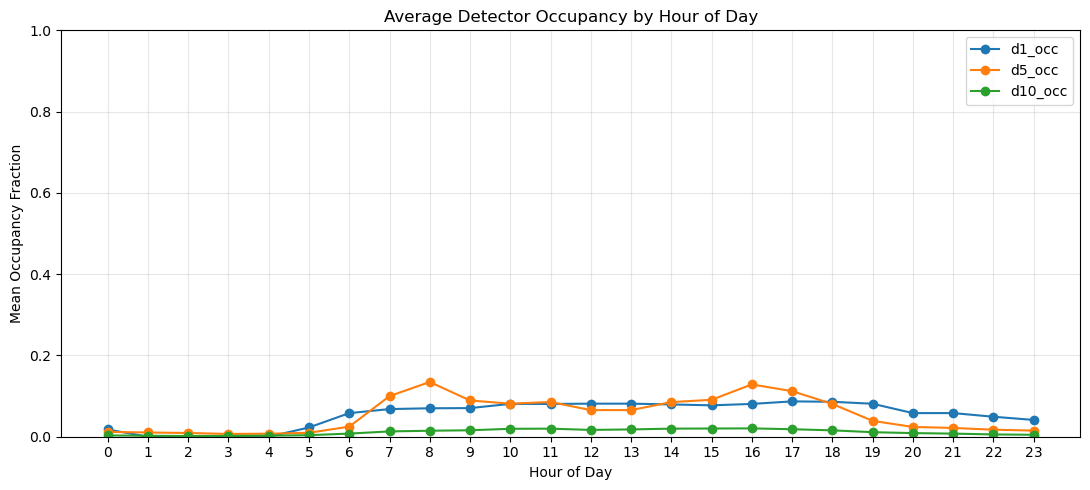

In [9]:
# Average occupancy by hour of day

# Use intervals with at least 90% time coverage
valid_occ = occ_5min[
    occ_5min["observed_seconds"] >= 270
].copy()

valid_occ["hour"] = valid_occ.index.hour

hourly_occupancy = (
    valid_occ.groupby("hour")[occupancy_cols].mean()
)

# Show the summary table
display(hourly_occupancy)

# Plot three detectors for readability
fig, ax = plt.subplots(figsize=(11, 5))

for detector in ["d1_occ", "d5_occ", "d10_occ"]:
    ax.plot(
        hourly_occupancy.index,
        hourly_occupancy[detector],
        marker="o",
        label=detector
    )

ax.set_title(
    "Average Detector Occupancy by Hour of Day"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Occupancy Fraction")

ax.set_xticks(range(24))
ax.set_ylim(0, 1)

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

fig.savefig(
    figures_dir / "hourly_detector_occupancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Anomaly Investigation

This section investigates unusually high detector occupancy.

High occupancy may reflect traffic congestion, vehicle
stopping behavior, or sensor problems.

A threshold of 0.90 is used as an initial diagnostic
rule, not as proof of a measurement error.

In [10]:
# Step 5: Investigate unusually high detector occupancy

# Use only complete 5-minute intervals
complete_occ = occ_5min[
    occ_5min["observed_seconds"] == 300
].copy()

# Define an initial diagnostic threshold
threshold = 0.90

# Identify high-occupancy intervals
high_occ = complete_occ[occupancy_cols] >= threshold

# Count flagged intervals for each detector
anomaly_summary = pd.DataFrame({
    "Detector": occupancy_cols,
    "High Occupancy Count": high_occ.sum().values,
    "Maximum Occupancy": complete_occ[
        occupancy_cols
    ].max().values
})

anomaly_summary["Flag Percentage"] = (
    anomaly_summary["High Occupancy Count"]
    / len(complete_occ) * 100
)

print("Complete 5-minute intervals:", len(complete_occ))
print("Diagnostic threshold:", threshold)

display(anomaly_summary)

# Find intervals where at least one detector is flagged
flagged_intervals = high_occ.any(axis=1)

print(
    "Intervals with at least one high-occupancy detector:",
    flagged_intervals.sum()
)

print("\nExample flagged intervals:")

display(
    complete_occ.loc[
        flagged_intervals,
        occupancy_cols
    ].head(10)
)

Complete 5-minute intervals: 16915
Diagnostic threshold: 0.9


,Detector,High Occupancy Count,Maximum Occupancy,Flag Percentage
0,d1_occ,2,1.000000,0.011824
1,d2_occ,0,0.666667,0.000000
2,d3_occ,0,0.253333,0.000000
3,d4_occ,8,0.993333,0.047295
4,d5_occ,0,0.783333,0.000000
5,d6_occ,0,0.333333,0.000000
6,d7_occ,0,0.540000,0.000000
7,d8_occ,0,0.630000,0.000000
8,d9_occ,0,0.856667,0.000000
9,d10_occ,0,0.193333,0.000000


Intervals with at least one high-occupancy detector: 10

Example flagged intervals:


,d1_occ,d2_occ,d3_occ,d4_occ,d5_occ,d6_occ,d7_occ,d8_occ,d9_occ,d10_occ
time,,,,,,,,,,
2019-01-10 10:25:00,0.000000,0.000000,0.000000,0.993333,0.073333,0.010000,0.133333,0.013333,0.070000,0.023333
2019-01-12 15:30:00,0.000000,0.010000,0.116667,0.910000,0.056667,0.163333,0.090000,0.030000,0.036667,0.030000
2019-01-15 10:25:00,1.000000,0.006667,0.010000,0.053333,0.073333,0.043333,0.083333,0.000000,0.060000,0.023333
2019-01-23 07:35:00,1.000000,0.006667,0.020000,0.010000,0.170000,0.026667,0.186667,0.013333,0.053333,0.023333
2019-02-17 16:30:00,0.176667,0.026667,0.023333,0.930000,0.136667,0.096667,0.130000,0.026667,0.040000,0.006667
2019-02-17 16:55:00,0.000000,0.000000,0.000000,0.920000,0.246667,0.063333,0.090000,0.000000,0.090000,0.016667
2019-02-23 16:10:00,0.043333,0.010000,0.010000,0.906667,0.090000,0.000000,0.093333,0.000000,0.050000,0.006667
2019-02-23 17:30:00,0.123333,0.016667,0.020000,0.903333,0.053333,0.150000,0.126667,0.026667,0.036667,0.013333
2019-02-24 14:40:00,0.130000,0.016667,0.020000,0.916667,0.060000,0.010000,0.083333,0.026667,0.050000,0.026667


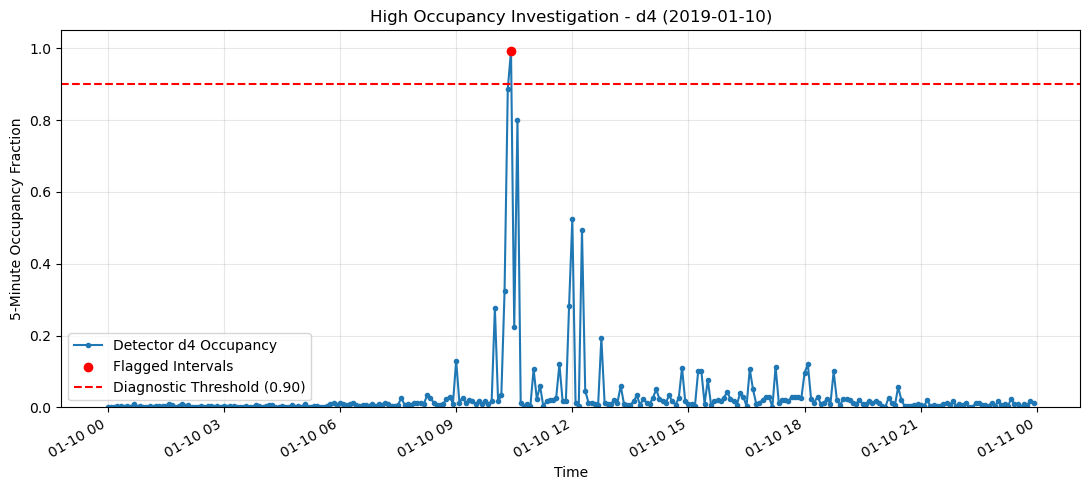

Selected date: 2019-01-10
Maximum occupancy: 0.9933333333333333
Flagged intervals on this date: 1


In [11]:
# Select detector d4 for investigation
detector = "d4_occ"

# Find the date containing the highest occupancy
peak_time = complete_occ[detector].idxmax()
selected_date = peak_time.date()

# Select observations from that date
daily_data = complete_occ.loc[
    complete_occ.index.date == selected_date
].copy()

# Identify high-occupancy points
flagged = daily_data[detector] >= threshold

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    daily_data.index,
    daily_data[detector],
    marker=".",
    label="Detector d4 Occupancy"
)

ax.scatter(
    daily_data.index[flagged],
    daily_data.loc[flagged, detector],
    color="red",
    label="Flagged Intervals",
    zorder=3
)

ax.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="Diagnostic Threshold (0.90)"
)

ax.set_title(
    f"High Occupancy Investigation - d4 ({selected_date})"
)

ax.set_xlabel("Time")
ax.set_ylabel("5-Minute Occupancy Fraction")

ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

fig.savefig(
    figures_dir / "d4_high_occupancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Selected date:", selected_date)
print("Maximum occupancy:", daily_data[detector].max())
print("Flagged intervals on this date:", int(flagged.sum()))

## 6. Temporal Dependence

This section investigates temporal dependence in detector
occupancy using lagged correlations.

We use a regular 5-minute time index and exclude incomplete
intervals to avoid treating missing periods as consecutive
observations.

The results will help us design a time-aware validation strategy.

In [12]:
# Create a complete 5-minute time index

full_index = pd.date_range(
    start="2019-01-01 00:00:00",
    end="2019-02-28 23:55:00",
    freq="5min"
)

# Reindex the occupancy dataset
full_occ = occ_5min.reindex(full_index)

# Keep only complete 5-minute intervals
valid_rows = full_occ["observed_seconds"] == 300

full_occ[occupancy_cols] = (
    full_occ[occupancy_cols].where(valid_rows)
)

print("Expected intervals:", len(full_index))
print("Complete intervals:", int(valid_rows.sum()))
print("Missing or incomplete intervals:",
      int((~valid_rows).sum()))

# Select detectors for temporal analysis
selected_detectors = [
    "d1_occ",
    "d4_occ",
    "d5_occ",
    "d7_occ"
]

# Lag values measured in 5-minute intervals
lags = [1, 2, 3, 6, 12, 24, 48, 288]

results = []

for detector in selected_detectors:

    series = full_occ[detector]

    for lag in lags:

        previous = series.shift(lag)

        # Use only pairs with two valid observations
        valid_pairs = (
            series.notna() & previous.notna()
        )

        correlation = series.corr(previous)

        results.append({
            "Detector": detector,
            "Lag": lag,
            "Lag Minutes": lag * 5,
            "Valid Pairs": int(valid_pairs.sum()),
            "Autocorrelation": correlation
        })

acf_df = pd.DataFrame(results)

display(
    acf_df.round(4)
)

Expected intervals: 16992
Complete intervals: 16915
Missing or incomplete intervals: 77


,Detector,Lag,Lag Minutes,Valid Pairs,Autocorrelation
0,d1_occ,1,5,16911,-0.0533
1,d1_occ,2,10,16907,0.3079
2,d1_occ,3,15,16904,0.2996
3,d1_occ,6,30,16901,0.5405
4,d1_occ,12,60,16895,0.4663
5,d1_occ,24,120,16883,0.3352
6,d1_occ,48,240,16859,0.1537
7,d1_occ,288,1440,16619,0.4846
8,d4_occ,1,5,16911,0.6826
9,d4_occ,2,10,16907,0.5918


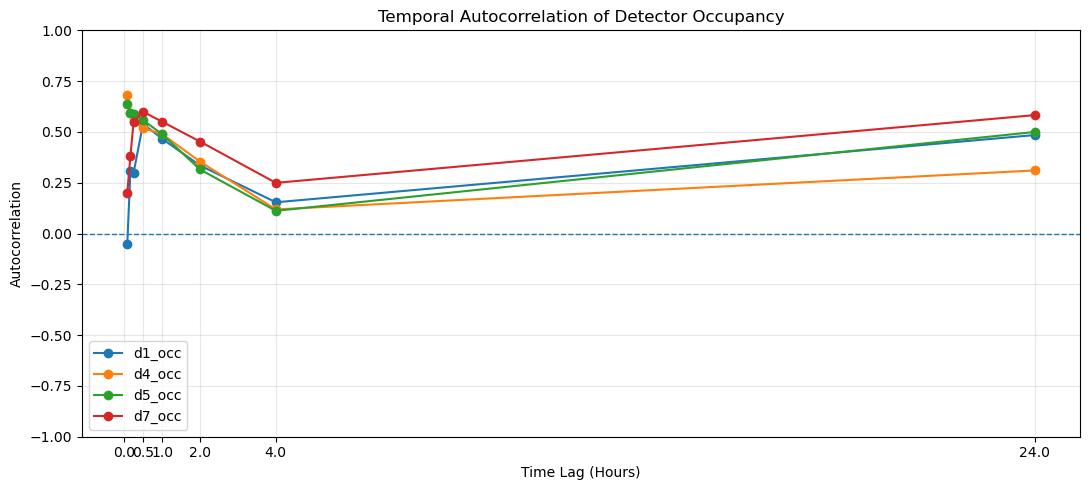

In [13]:
# Plot lagged correlations

fig, ax = plt.subplots(figsize=(11, 5))

for detector in selected_detectors:

    subset = acf_df[
        acf_df["Detector"] == detector
    ]

    ax.plot(
        subset["Lag Minutes"] / 60,
        subset["Autocorrelation"],
        marker="o",
        label=detector
    )

ax.axhline(
    0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Temporal Autocorrelation of Detector Occupancy"
)

ax.set_xlabel("Time Lag (Hours)")
ax.set_ylabel("Autocorrelation")

ax.set_xticks(
    [0, 0.5, 1, 2, 4, 24]
)

ax.set_ylim(-1, 1)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    figures_dir / "temporal_autocorrelation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Leakage Risk and Preliminary Validation

We define a one-step-ahead prediction task using
5-minute detector occupancy.

The input contains information observed during the
current interval. The target is d5 occupancy in the
next 5-minute interval.

We preserve chronological order and separate the data
into training, validation, and test periods.

No future detector states or signal states are used
as prediction features.

In [14]:
# Step 7: Prepare the prediction dataset

# Use the regular 5-minute time series from Step 6
prediction_df = full_occ[occupancy_cols].copy()

# Target: d5 occupancy in the NEXT 5-minute interval
prediction_df["target_d5_next"] = (
    prediction_df["d5_occ"].shift(-1)
)

# Timestamp of the target interval
prediction_df["target_time"] = (
    prediction_df.index + pd.Timedelta(minutes=5)
)

# Context features available at decision time
prediction_df["hour"] = prediction_df.index.hour
prediction_df["day_of_week"] = (
    prediction_df.index.dayofweek
)

# Remove rows with incomplete current observations
# or missing future targets
prediction_df = prediction_df.dropna(
    subset=occupancy_cols + ["target_d5_next"]
).copy()

print("Valid prediction samples:", len(prediction_df))

display(prediction_df.head())

Valid prediction samples: 16911


,d1_occ,d2_occ,d3_occ,d4_occ,d5_occ,d6_occ,d7_occ,d8_occ,d9_occ,d10_occ,target_d5_next,target_time,hour,day_of_week
2019-01-01 05:40:00,0.000000,0.000000,0.000000,0.010000,0.020000,0.000000,0.020000,0.000000,0.020000,0.010000,0.033333,2019-01-01 05:45:00,5,1
2019-01-01 05:45:00,0.086667,0.016667,0.020000,0.026667,0.033333,0.066667,0.093333,0.030000,0.016667,0.006667,0.043333,2019-01-01 05:50:00,5,1
2019-01-01 05:50:00,0.000000,0.000000,0.000000,0.016667,0.043333,0.013333,0.083333,0.000000,0.036667,0.006667,0.006667,2019-01-01 05:55:00,5,1
2019-01-01 05:55:00,0.000000,0.000000,0.000000,0.170000,0.006667,0.016667,0.073333,0.000000,0.030000,0.003333,0.010000,2019-01-01 06:00:00,5,1
2019-01-01 06:00:00,0.093333,0.013333,0.016667,0.006667,0.010000,0.000000,0.000000,0.023333,0.010000,0.010000,0.016667,2019-01-01 06:05:00,6,1


In [15]:
# Define split boundaries
train_end = pd.Timestamp("2019-02-01")
val_end = pd.Timestamp("2019-02-16")
test_end = pd.Timestamp("2019-03-01")

# Training: January
train_df = prediction_df[
    (prediction_df.index < train_end) &
    (prediction_df["target_time"] < train_end)
].copy()

# Validation: February 1–15
val_df = prediction_df[
    (prediction_df.index >= train_end) &
    (prediction_df["target_time"] < val_end)
].copy()

# Test: February 16–28
test_df = prediction_df[
    (prediction_df.index >= val_end) &
    (prediction_df["target_time"] < test_end)
].copy()

# Summarize the splits
split_summary = pd.DataFrame([
    {
        "Split": "Training",
        "Samples": len(train_df),
        "Start": train_df.index.min(),
        "End": train_df.index.max()
    },
    {
        "Split": "Validation",
        "Samples": len(val_df),
        "Start": val_df.index.min(),
        "End": val_df.index.max()
    },
    {
        "Split": "Test",
        "Samples": len(test_df),
        "Start": test_df.index.min(),
        "End": test_df.index.max()
    }
])

display(split_summary)

# Check time ordering
assert train_df.index.max() < val_df.index.min()
assert val_df.index.max() < test_df.index.min()

# Check that every target stays within its split
assert (train_df["target_time"] < train_end).all()
assert (
    (val_df["target_time"] >= train_end) &
    (val_df["target_time"] < val_end)
).all()
assert (
    (test_df["target_time"] >= val_end) &
    (test_df["target_time"] < test_end)
).all()

print("Chronological validation split completed.")
print("No targets cross the split boundaries.")

,Split,Samples,Start,End
0,Training,8855,2019-01-01 05:40:00,2019-01-31 23:45:00
1,Validation,4316,2019-02-01 00:10:00,2019-02-15 23:45:00
2,Test,3740,2019-02-16 00:10:00,2019-02-28 23:45:00


Chronological validation split completed.
No targets cross the split boundaries.


## 8. Baseline Analysis

Two baseline methods are evaluated:

1. Persistence baseline: the next occupancy is predicted
   using the current occupancy.

2. Time-of-day baseline: the next occupancy is predicted
   using the historical mean for the corresponding hour.

The time-of-day averages are estimated using only
the training data.

Mean Absolute Error (MAE) is used to compare predictions
on the validation dataset.

In [16]:
# Step 8: Baseline prediction and evaluation

# Actual values in validation set
y_val = val_df["target_d5_next"]

# ----------------------------------------
# Baseline 1: Persistence
# ----------------------------------------

# Predict next occupancy = current occupancy
pred_persistence = val_df["d5_occ"].copy()


# ----------------------------------------
# Baseline 2: Time-of-Day Average
# ----------------------------------------

# Use the hour of the TARGET interval
train_target_hour = train_df["target_time"].dt.hour
val_target_hour = val_df["target_time"].dt.hour

# Calculate hourly averages using TRAINING data only
hourly_means = train_df.groupby(
    train_target_hour
)["target_d5_next"].mean()

# Apply learned averages to validation data
pred_tod = val_target_hour.map(hourly_means)

# Fallback if an hour is absent from training data
train_mean = train_df["target_d5_next"].mean()
pred_tod = pred_tod.fillna(train_mean)

# ----------------------------------------
# Calculate Mean Absolute Error
# ----------------------------------------

def calculate_mae(actual, predicted):
    return np.mean(np.abs(
        np.asarray(actual) - np.asarray(predicted)
    ))

mae_persistence = calculate_mae(
    y_val, pred_persistence
)

mae_tod = calculate_mae(
    y_val, pred_tod
)

baseline_results = pd.DataFrame({
    "Baseline": [
        "Persistence",
        "Time-of-Day"
    ],
    "Validation MAE": [
        mae_persistence,
        mae_tod
    ]
})

display(baseline_results)

print("Persistence MAE:", round(mae_persistence, 6))
print("Time-of-Day MAE:", round(mae_tod, 6))

print(
    "Lower validation MAE:",
    baseline_results.loc[
        baseline_results["Validation MAE"].idxmin(),
        "Baseline"
    ]
)

,Baseline,Validation MAE
0,Persistence,0.031815
1,Time-of-Day,0.030615


Persistence MAE: 0.031815
Time-of-Day MAE: 0.030615
Lower validation MAE: Time-of-Day


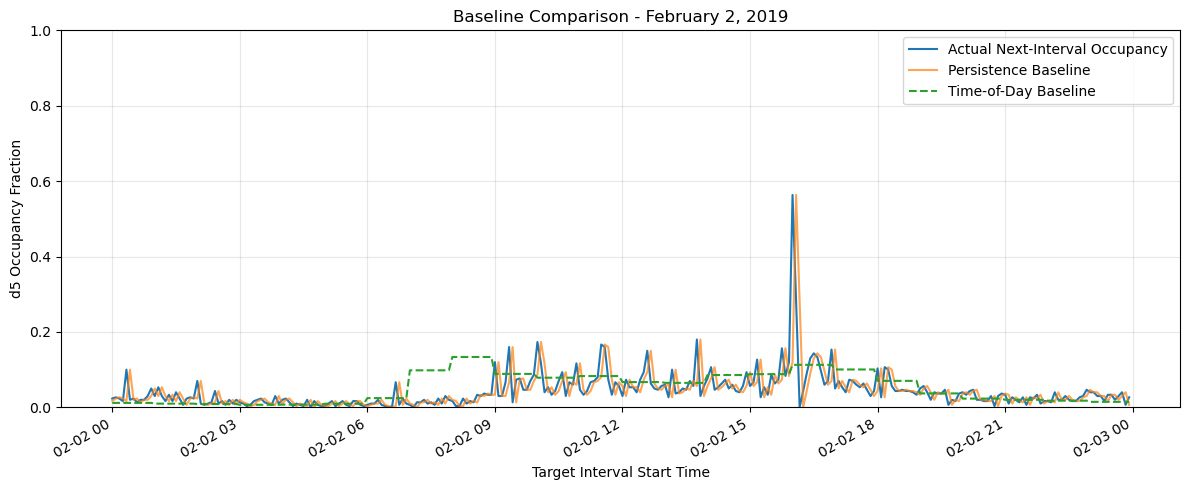

In [17]:
# Corrected baseline comparison using target timestamps

validation_predictions = pd.DataFrame({
    "Actual": val_df["target_d5_next"].to_numpy(),
    "Persistence": pred_persistence.to_numpy(),
    "Time-of-Day": pred_tod.to_numpy()
}, index=pd.DatetimeIndex(
    val_df["target_time"],
    name="target_time"
))

selected_day = validation_predictions.loc["2019-02-02"]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    selected_day.index,
    selected_day["Actual"],
    label="Actual Next-Interval Occupancy"
)

ax.plot(
    selected_day.index,
    selected_day["Persistence"],
    label="Persistence Baseline",
    alpha=0.7
)

ax.plot(
    selected_day.index,
    selected_day["Time-of-Day"],
    label="Time-of-Day Baseline",
    linestyle="--"
)

ax.set_title("Baseline Comparison - February 2, 2019")
ax.set_xlabel("Target Interval Start Time")
ax.set_ylabel("d5 Occupancy Fraction")

ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()

fig.savefig(
    figures_dir / "baseline_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Baseline Results and Interpretation

The persistence baseline achieved a validation MAE of
0.031815, while the time-of-day baseline achieved 0.030615.

The time-of-day baseline reduced MAE by approximately 3.77%
compared with persistence.

This suggests that daily traffic patterns provide useful
information for predicting detector occupancy.

However, both methods have difficulty predicting sudden
changes in occupancy.

These results measure prediction accuracy, not the quality
of signal timing decisions.

In [18]:
# Step 9: Final reproducibility checks

assert total_rows == 5076422
assert len(occ_5min) == 16923
assert len(complete_occ) == 16915
assert len(prediction_df) == 16911

assert len(train_df) == 8855
assert len(val_df) == 4316
assert len(test_df) == 3740

assert np.isfinite(mae_persistence)
assert np.isfinite(mae_tod)

assert 0 <= mae_persistence <= 1
assert 0 <= mae_tod <= 1

print("All reproducibility checks passed.")

print("\nValidation results:")
display(baseline_results.round(6))

print("\nGenerated figures:")
for file in sorted(figures_dir.glob("*.png")):
    print(file.name)

All reproducibility checks passed.

Validation results:


,Baseline,Validation MAE
0,Persistence,0.031815
1,Time-of-Day,0.030615



Generated figures:
baseline_comparison.png
d4_high_occupancy.png
hourly_detector_occupancy.png
signal_code8_by_hour.png
temporal_autocorrelation.png
